Testowanie działania tych samych modeli, ale w środowisku GPU, aby ocenić wpływ ograniczeń sprzętowych na czas uczenia oraz wygodę eksperymentowania.

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras import layers
from keras.utils import to_categorical
import pickle


In [ ]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [ ]:
print(type(X_train))
print(type(y_train))
print(type(X_test))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
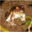

In [ ]:
# przyjrzenie się pierwszemu zdjęciu
index = 0
X_train[index]

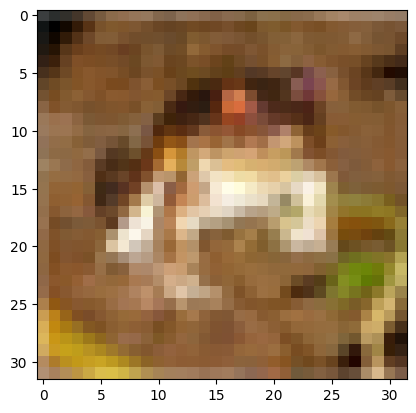

In [ ]:
# wyswietlenie juz jako obrazu
img = plt.imshow(X_train[index])

In [ ]:
# znalezienie etykiety obrazu
print('Etykieta klasy', y_train[index])

Etykieta klasy [6]


In [ ]:
# kazda liczba odpowiada nazyw klasy
classification = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("Numer klasy:", y_train[index][0])
print("Nazwa klasy:", classification[y_train[index][0]])

Numer klasy: 6
Nazwa klasy: frog


In [ ]:
klasy, liczba = np.unique(y_train, return_counts=True)

for k, l in zip(klasy, liczba):
    print(f"{k} - {classification[k]}: {l} obrazów")

0 - airplane: 5000 obrazów
1 - automobile: 5000 obrazów
2 - bird: 5000 obrazów
3 - cat: 5000 obrazów
4 - deer: 5000 obrazów
5 - dog: 5000 obrazów
6 - frog: 5000 obrazów
7 - horse: 5000 obrazów
8 - ship: 5000 obrazów
9 - truck: 5000 obrazów


array([[[53, 65, 53],
        [54, 63, 52],
        [56, 60, 50],
        ...,
        [47, 51, 50],
        [41, 45, 44],
        [24, 28, 27]],

       [[46, 59, 41],
        [53, 62, 45],
        [54, 59, 44],
        ...,
        [42, 46, 45],
        [39, 43, 42],
        [28, 32, 31]],

       [[45, 59, 38],
        [50, 60, 41],
        [46, 52, 34],
        ...,
        [38, 42, 41],
        [36, 40, 39],
        [29, 33, 32]],

       ...,

       [[71, 83, 66],
        [74, 83, 66],
        [80, 85, 67],
        ...,
        [51, 54, 33],
        [46, 49, 34],
        [49, 50, 41]],

       [[75, 82, 67],
        [79, 85, 69],
        [81, 85, 67],
        ...,
        [61, 65, 41],
        [64, 67, 48],
        [48, 50, 41]],

       [[85, 83, 71],
        [85, 84, 71],
        [86, 86, 70],
        ...,
        [61, 65, 39],
        [64, 67, 46],
        [49, 50, 41]]], dtype=uint8)
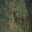

In [ ]:
index = 10
X_train[index]

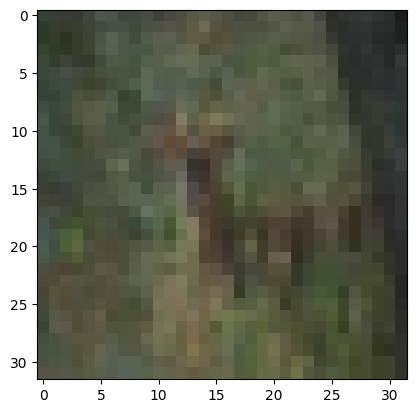

In [ ]:
img = plt.imshow(X_train[index])

In [ ]:
print("Numer klasy:", y_train[index][0])
print("Nazwa klasy:", classification[y_train[index][0]])

Numer klasy: 4
Nazwa klasy: deer


In [ ]:
y_train[:11]

array([[6],
       [9],
       [9],
       [4],
       [1],
       [1],
       [2],
       [7],
       [8],
       [3],
       [4]], dtype=uint8)

In [ ]:
# przygotowanie danych - przekonwertowanie danych na zestaw 10 liczb
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

In [ ]:
print(y_train_one_hot)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


In [ ]:
# wydrukowanie nowej etykiety
print('zakodowana etykieta:', y_train_one_hot[index])

zakodowana etykieta: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [ ]:
# normalizacja pikseli na wartość 0/1
X_train = X_train / 255
X_test = X_test / 255

In [ ]:
X_train[index]

array([[[0.20784314, 0.25490196, 0.20784314],
        [0.21176471, 0.24705882, 0.20392157],
        [0.21960784, 0.23529412, 0.19607843],
        ...,
        [0.18431373, 0.2       , 0.19607843],
        [0.16078431, 0.17647059, 0.17254902],
        [0.09411765, 0.10980392, 0.10588235]],

       [[0.18039216, 0.23137255, 0.16078431],
        [0.20784314, 0.24313725, 0.17647059],
        [0.21176471, 0.23137255, 0.17254902],
        ...,
        [0.16470588, 0.18039216, 0.17647059],
        [0.15294118, 0.16862745, 0.16470588],
        [0.10980392, 0.1254902 , 0.12156863]],

       [[0.17647059, 0.23137255, 0.14901961],
        [0.19607843, 0.23529412, 0.16078431],
        [0.18039216, 0.20392157, 0.13333333],
        ...,
        [0.14901961, 0.16470588, 0.16078431],
        [0.14117647, 0.15686275, 0.15294118],
        [0.11372549, 0.12941176, 0.1254902 ]],

       ...,

       [[0.27843137, 0.3254902 , 0.25882353],
        [0.29019608, 0.3254902 , 0.25882353],
        [0.31372549, 0

In [ ]:
model = Sequential()

model.add(Conv2D(32,(5,5), activation='relu', input_shape=(32,32,3)))

model.add(MaxPooling2D((2,2)))
model.add(Conv2D(32,(5,5), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(1000, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(500, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(250, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
hist = model.fit(X_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=1 )

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.2736 - loss: 1.9179 - val_accuracy: 0.4176 - val_loss: 1.5627
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4405 - loss: 1.5214 - val_accuracy: 0.5082 - val_loss: 1.3659
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4985 - loss: 1.3895 - val_accuracy: 0.5513 - val_loss: 1.2626
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5378 - loss: 1.2951 - val_accuracy: 0.5506 - val_loss: 1.2636
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5654 - loss: 1.2222 - val_accuracy: 0.5965 - val_loss: 1.1444
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5905 - loss: 1.1500 - val_accuracy: 0.5902 - val_loss: 1.1531
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6084 - loss: 1.1091 - val_accuracy: 0.6165 - val_loss: 1.0834
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6290 - loss: 1.0525 - val_accu

In [ ]:
model.evaluate(X_test, y_test_one_hot)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6362 - loss: 1.0361


0.6362000107765198

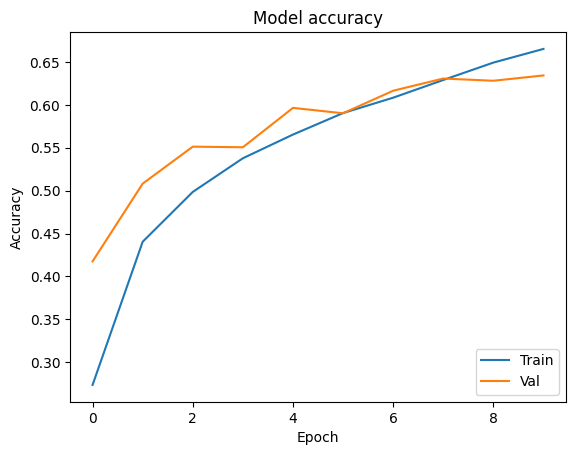

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')

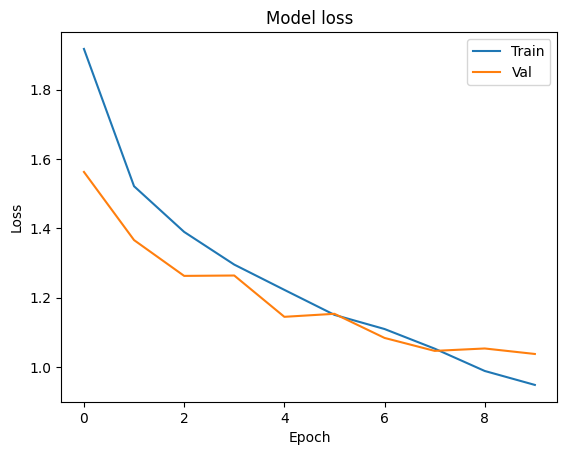

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')

In [ ]:
# przetestowanie konkretnego zdjęcia
from google.colab import files
uploaded = files.upload()

Saving cat1.jpg to cat1.jpg


array([[[185, 211, 236],
        [185, 211, 236],
        [185, 211, 236],
        ...,
        [193, 208, 228],
        [193, 208, 228],
        [193, 208, 228]],

       [[185, 211, 236],
        [185, 211, 236],
        [185, 211, 236],
        ...,
        [193, 208, 228],
        [193, 208, 228],
        [193, 208, 228]],

       [[185, 211, 236],
        [185, 211, 236],
        [185, 211, 236],
        ...,
        [193, 208, 228],
        [193, 208, 228],
        [193, 208, 228]],

       ...,

       [[171, 179, 202],
        [171, 179, 202],
        [171, 179, 202],
        ...,
        [190, 194, 211],
        [191, 193, 211],
        [191, 193, 211]],

       [[171, 179, 202],
        [171, 179, 202],
        [171, 179, 202],
        ...,
        [190, 193, 213],
        [191, 193, 213],
        [191, 193, 213]],

       [[171, 179, 202],
        [171, 179, 202],
        [171, 179, 202],
        ...,
        [190, 193, 213],
        [191, 193, 213],
        [191, 193, 213]]], dtype=uint8)
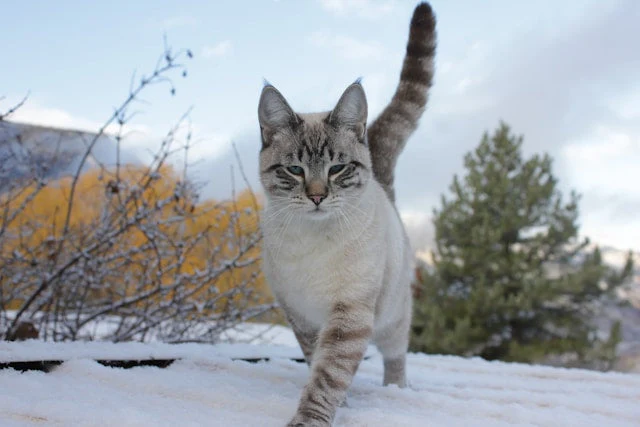

In [ ]:
new_image = plt.imread('cat1.jpg')
new_image

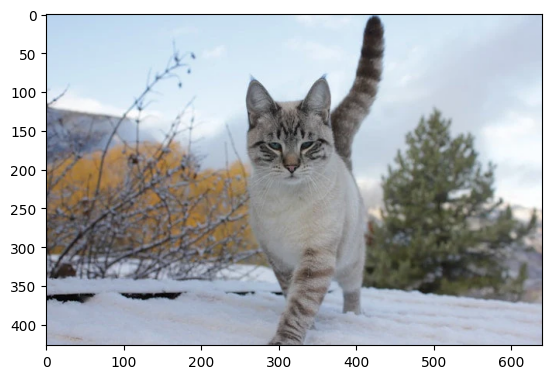

In [ ]:
new_image = plt.imread('cat1.jpg')
img = plt.imshow(new_image)

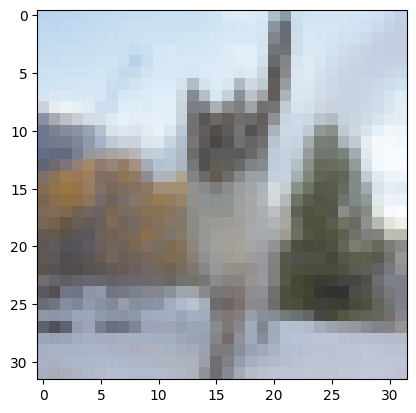

In [ ]:
# zmiana rozmiaru na 32x32
from skimage.transform import resize
resized_image = resize(new_image, (32,32,3))
img = plt.imshow(resized_image)

In [ ]:
# przewidzenie obrazu przez model
predictions = model.predict(np.array([resized_image]))

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step


array([[0.0279363 , 0.0015689 , 0.21914451, 0.24776234, 0.11821149,
        0.2488594 , 0.01118054, 0.11456671, 0.00640051, 0.00436924]],
      dtype=float32)

In [ ]:
# uzyskanie najwyższej wartości z przewidywanych
list_index = [0,1,2,3,4,5,6,7,8,9]
x = predictions

for i in range(10):
  for j in range(10):
    if x[0][list_index[i]] > x[0][list_index[j]]:
      temp = list_index[i]
      list_index[i] = list_index[j]
      list_index[j] = temp

print(list_index)

[5, 3, 2, 4, 7, 0, 6, 8, 9, 1]


In [ ]:
for i in range(5):
  print(classification[list_index[i]], ':', round(predictions[0][list_index[i]] * 100, 2), '%')

dog : 24.89 %
cat : 24.78 %
bird : 21.91 %
deer : 11.82 %
horse : 11.46 %


In [ ]:
#model.save('cifar10_model.h5')

#model.save("cifar10_model.keras")

In [ ]:
#from google.colab import files

#model.save("cifar10_model.keras")
#files.download("cifar10_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# model.save("/content/drive/MyDrive/cifar10_model.keras")

Mounted at /content/drive


In [ ]:
# from keras.models import load_model

#model = load_model("cifar10_model.keras")

#loss, acc = model.evaluate(X_test, y_test_one_hot)
#print(acc)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6362 - loss: 1.0361
0.6362000107765198


Ulepszony model

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
batch_size = 128

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train_one_hot))
train_ds = train_ds.shuffle(50000)

# augmentacja tylko na treningu
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_one_hot))
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))

model.add(tf.keras.layers.Conv2D(32, (3,3), padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Conv2D(64, (3,3), padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))

model.add(tf.keras.layers.Conv2D(64, (3,3), padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(256))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)


In [ ]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 180ms/step - accuracy: 0.3923 - loss: 1.7401 - val_accuracy: 0.3190 - val_loss: 2.0661 - learning_rate: 5.0000e-04
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 61s 156ms/step - accuracy: 0.5009 - loss: 1.3904 - val_accuracy: 0.5653 - val_loss: 1.2199 - learning_rate: 5.0000e-04
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 64s 165ms/step - accuracy: 0.5539 - loss: 1.2530 - val_accuracy: 0.5958 - val_loss: 1.1130 - learning_rate: 5.0000e-04
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 164ms/step - accuracy: 0.5856 - loss: 1.1658 - val_accuracy: 0.6143 - val_loss: 1.1338 - learning_rate: 5.0000e-04
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 65s 166ms/step - accuracy: 0.6127 - loss: 1.0981 - val_accuracy: 0.6242 - val_loss: 1.0543 - learning_rate: 5.0000e-04
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 168ms/step - accuracy: 0.6266 - loss: 1.0524 - val_accuracy: 0.6276 - val_loss: 1.0659 - learning_rate: 5.0000e-04
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 64s 16

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7131 - loss: 0.8271
0.713100016117096


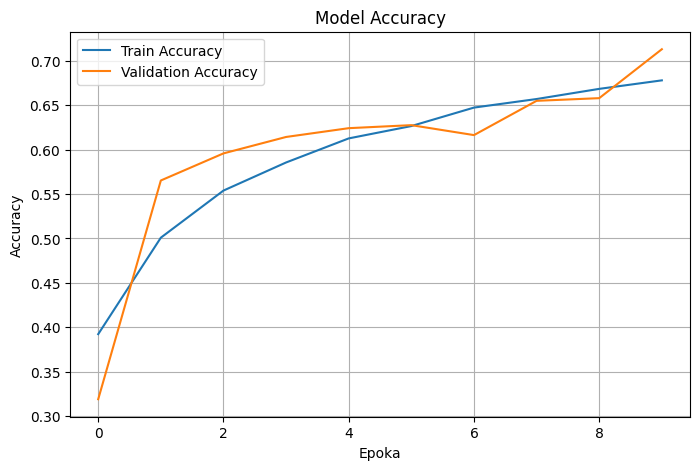

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

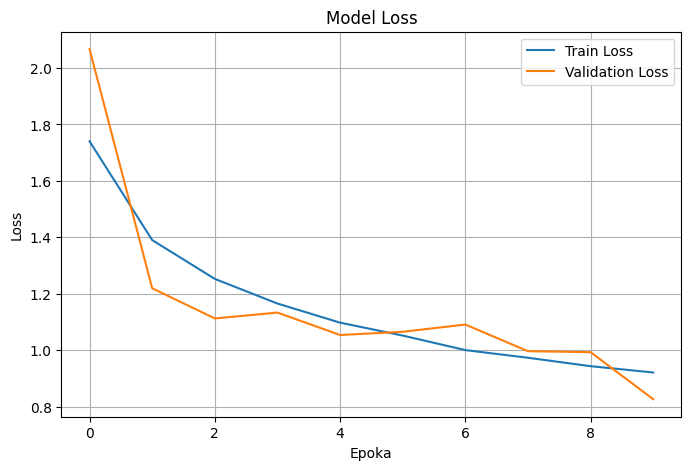

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7131 - loss: 0.8271
Test loss     : 0.8271
Test accuracy : 0.7131


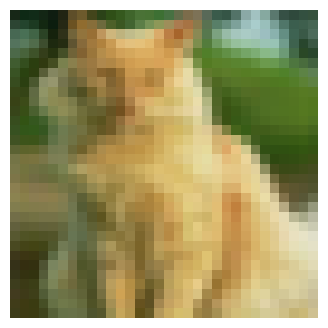

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prawdziwa klasa: cat
Predykcja modelu: frog
Pewność: 0.23726721


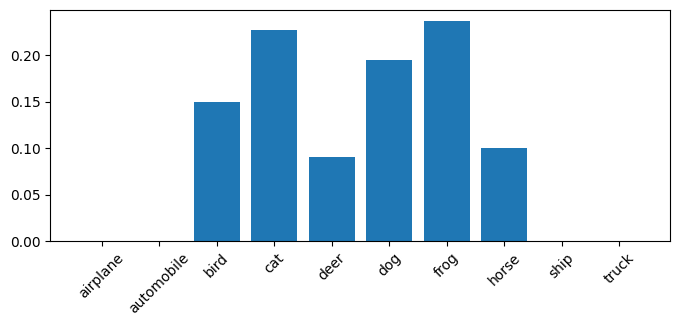

In [ ]:
idx = 18787 #@param {type:"slider", min:0, max:49999}

img = X_train[idx]

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.show()

# predykcja modelu
pred = model.predict(np.array([img]))[0]

# najlepsza klasa
pred_class = classification[np.argmax(pred)]
print("Prawdziwa klasa:", classification[y_train[idx][0]])
print("Predykcja modelu:", pred_class)
print("Pewność:", np.max(pred))

# wizualizacja prawdopodobieństw
plt.figure(figsize=(8,3))
plt.bar(classification, pred)
plt.xticks(rotation=45)
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dog.jpg to dog.jpg


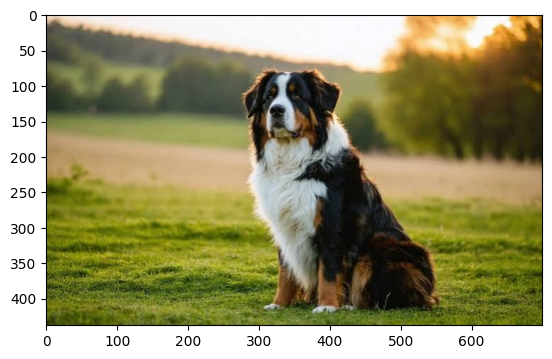

In [ ]:
new_image1 = plt.imread('dog.jpg')
img1 = plt.imshow(new_image1)

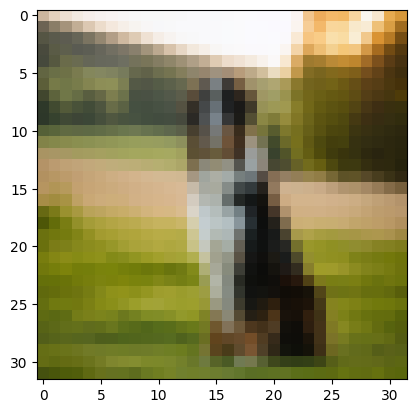

In [ ]:
from skimage.transform import resize
resized_image1 = resize(new_image1, (32,32,3))
img1 = plt.imshow(resized_image1)

In [ ]:
predictions1 = model.predict(np.array([resized_image1]))
predictions1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[4.7330219e-02, 4.6072103e-02, 1.1906805e-01, 2.4213251e-02,
        5.1272616e-02, 2.0322587e-01, 3.0343584e-04, 4.5750752e-01,
        1.2474905e-03, 4.9759485e-02]], dtype=float32)

In [ ]:
klasy, liczba = np.unique(y_train, return_counts=True)

for k, l in zip(klasy, liczba):
    print(f"{k} - {classification[k]}: {l} obrazów")

0 - airplane: 5000 obrazów
1 - automobile: 5000 obrazów
2 - bird: 5000 obrazów
3 - cat: 5000 obrazów
4 - deer: 5000 obrazów
5 - dog: 5000 obrazów
6 - frog: 5000 obrazów
7 - horse: 5000 obrazów
8 - ship: 5000 obrazów
9 - truck: 5000 obrazów


In [ ]:
list_index = [0,1,2,3,4,5,6,7,8,9]
x = predictions1

for i in range(10):
  for j in range(10):
    if x[0][list_index[i]] > x[0][list_index[j]]:
      temp = list_index[i]
      list_index[i] = list_index[j]
      list_index[j] = temp

print(list_index)

[7, 5, 2, 4, 9, 0, 1, 3, 8, 6]


In [ ]:
for i in range(5):
  print(classification[list_index[i]], ':', round(predictions1[0][list_index[i]] * 100, 2), '%')

horse : 45.75 %
dog : 20.32 %
bird : 11.91 %
deer : 5.13 %
truck : 4.98 %


In [ ]:
#from google.colab import files

#model.save("cifar10_model2.keras")
#files.download("cifar10_model2.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#from tensorflow.keras.models import load_model

#model2 = load_model("cifar10_model2.keras")

In [ ]:
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 3,354,496 (12.80 MB)

 Trainable params: 1,117,866 (4.26 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 2,235,734 (8.53 MB)

### Podsumowanie
| Model CNN | Accuracy | Loss |
|-------|---------:|------------------:|
| Model prosty | 63.6 % | 1.03 |
| Model Ulepszony | 71.3 % | 0.82 |
- Prosty model CNN osiągnął dokładność testową około 63.6%, co oznacza, że poprawnie klasyfikuje nieco ponad połowę obrazów, ale ma ograniczoną zdolność rozróżniania podobnych klas.
- Ulepszony model CNN osiągnął wyraźnie lepszy wynik około 71.3% dokładności. Dzięki zastosowaniu Batch Normalization, Dropoutu, większej liczby filtrów oraz augmentacji danych, model lepiej generalizuje i skuteczniej uczy się cech obrazów. Widać również bardziej stabilny przebieg uczenia oraz niższy loss, co oznacza mniejszą liczbę błędów i lepsze dopasowanie do danych testowych.

### CPU vs GPU - czas epoki
- Wersja CPU dla prostego modelu: czas jednej epoki wynosił około 60-80 sekund lub więcej, a dla ulepszonego modelu nawet: 5-10 minut
- Wersja GPU dla prostego modelu: czas dla 1) epoki wyniósł 19 sek, kolejne około 1-6 sek, a dla ulepszonego modelu 1) epoka wyniosła 82 sek, potem kolejne 60-65 sek.
- Na GPU oba modele uczą się znacznie szybciej niż na CPU, co pozwala na częstsze eksperymenty i lepsze strojenie architektury. Podsumowując, ulepszony model CNN jest wyraźnym krokiem naprzód względem prostego modelu zarówno pod względem dokładności, jak i stabilności uczenia, a wykorzystanie GPU znacząco usprawnia cały proces eksperymentowania i trenowania sieci neuronowych.